# Notebook 5: CNNs, Training Recipes & Overparameterization

**Series 2, Week 2 — PyTorch**

---

## What We'll Build

In the previous notebooks you built MLPs that treated images as flat vectors — every pixel
connected to every neuron, with no notion of spatial structure. That works for small images,
but it's wildly inefficient: a 32×32 colour image has 3,072 pixels, and a single fully-connected
layer with 512 neurons already needs **1.6 million** weights.

In this notebook we introduce **Convolutional Neural Networks (CNNs)**, which exploit the
spatial structure of images by sharing small filters across the image. Then we run a
systematic **ablation study** to learn that the *training recipe* — initialization, normalization,
augmentation, scheduling — matters at least as much as the architecture itself.

We'll also witness one of the most surprising facts in modern deep learning: a model with
**millions of parameters** trained on only **1,000 images** can still generalize. Classical
statistics says it shouldn't. We'll see that it does.

### Curriculum points covered
| # | Point | Section |
|---|-------|---------|
| ③ | Overparameterization helps | §6 |
| ⑥ | Geometry matters | §4–5 |
| ⑦ | Capacity ≠ performance | §4 |

## Setup

Let's import everything we need and set global seeds for reproducibility.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from copy import deepcopy
import time
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# -- Reproducibility ----------------------------------------
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Use CPU -- this notebook is designed to run on a laptop
DEVICE = torch.device("cpu")

print(f"PyTorch version : {torch.__version__}")
print(f"Torchvision     : {torchvision.__version__}")
print(f"Device          : {DEVICE}")

PyTorch version : 2.10.0+cpu
Torchvision     : 0.25.0+cpu
Device          : cpu


---

## 2. Convolution from Scratch

### What a convolution does

A 2D convolution slides a small **filter** (or **kernel**) across an image and at each
position computes a dot product between the filter weights and the local patch of pixels.
This produces a **feature map** that highlights where the pattern encoded in the filter
appears in the image.

Key properties:
- **Parameter sharing** — the same filter weights are reused everywhere in the image
- **Translation equivariance** — if the input shifts, the feature map shifts the same way
- **Locality** — each output pixel depends only on a small neighbourhood of input pixels

Let's implement a single 2D convolution in pure NumPy first, so you understand exactly
what `nn.Conv2d` does under the hood.

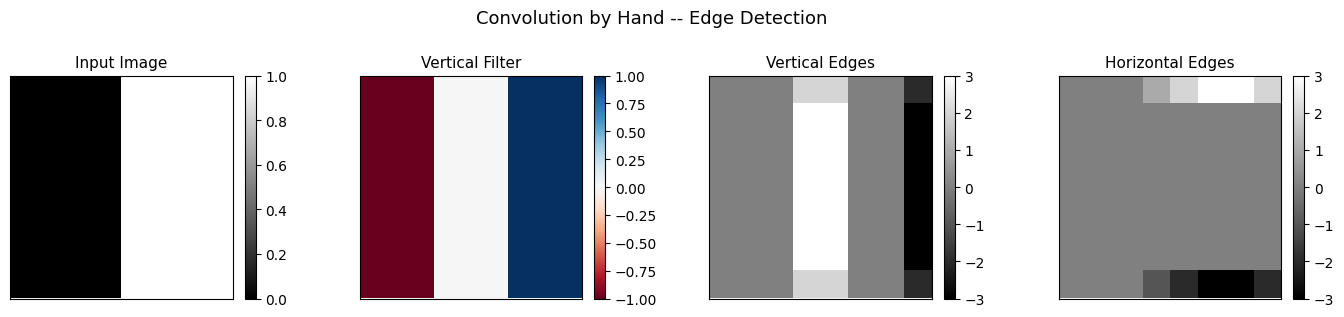

Our hand-written convolution detected the vertical edge perfectly.


In [2]:
def conv2d_numpy(image, kernel, stride=1, padding=0):
    """Apply a single 2D convolution filter to a single-channel image.

    Parameters
    ----------
    image  : np.ndarray, shape (H, W)
    kernel : np.ndarray, shape (kH, kW)
    stride : int
    padding: int (zero-padding)

    Returns
    -------
    np.ndarray -- the feature map
    """
    # Pad the image
    if padding > 0:
        image = np.pad(image, padding, mode='constant', constant_values=0)

    H, W = image.shape
    kH, kW = kernel.shape

    # Output dimensions
    out_h = (H - kH) // stride + 1
    out_w = (W - kW) // stride + 1

    output = np.zeros((out_h, out_w))

    for i in range(out_h):
        for j in range(out_w):
            # Extract the local patch
            patch = image[i*stride : i*stride + kH,
                          j*stride : j*stride + kW]
            # Dot product
            output[i, j] = np.sum(patch * kernel)

    return output


# -- Demo: edge-detection kernels on a simple image ----------
np.random.seed(SEED)

# Create a simple 8x8 image with a vertical edge
img = np.zeros((8, 8))
img[:, 4:] = 1.0  # right half is white

# Vertical edge detector and horizontal edge detector
kernel_v = np.array([[-1, 0, 1],
                     [-1, 0, 1],
                     [-1, 0, 1]], dtype=float)

kernel_h = np.array([[-1, -1, -1],
                     [ 0,  0,  0],
                     [ 1,  1,  1]], dtype=float)

feat_v = conv2d_numpy(img, kernel_v, padding=1)
feat_h = conv2d_numpy(img, kernel_h, padding=1)

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
titles = ["Input Image", "Vertical Filter", "Vertical Edges", "Horizontal Edges"]
data   = [img, kernel_v, feat_v, feat_h]
cmaps  = ["gray", "RdBu", "gray", "gray"]

for ax, title, d, cm in zip(axes, titles, data, cmaps):
    im = ax.imshow(d, cmap=cm)
    ax.set_title(title, fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle("Convolution by Hand -- Edge Detection", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()
print("Our hand-written convolution detected the vertical edge perfectly.")

### From NumPy to PyTorch: `nn.Conv2d`

PyTorch's `nn.Conv2d` does exactly the same sliding-window dot product, but:
- Handles **batches** of multi-channel images
- Runs on GPU if available
- Tracks gradients automatically for backprop
- Is implemented in highly-optimized C++/CUDA

Let's verify that our NumPy result matches PyTorch's.

In [3]:
# Build the same vertical-edge kernel in PyTorch
conv_pt = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3, padding=1, bias=False)

# Manually set the weights to our kernel
with torch.no_grad():
    conv_pt.weight[0, 0] = torch.tensor(kernel_v, dtype=torch.float32)

# Prepare input: PyTorch expects (batch, channels, H, W)
img_tensor = torch.tensor(img, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

feat_pt = conv_pt(img_tensor).squeeze().detach().numpy()

# Compare
diff = np.abs(feat_v - feat_pt).max()
print(f"Max absolute difference between NumPy and PyTorch conv: {diff:.2e}")
print("Remember when you built matrix multiply from scratch in the pure-Python notebooks?")
print("Same idea -- understand it manually, then use the optimized version.")

Max absolute difference between NumPy and PyTorch conv: 0.00e+00
Remember when you built matrix multiply from scratch in the pure-Python notebooks?
Same idea -- understand it manually, then use the optimized version.


---

## 3. Building a CNN for CIFAR-10

[CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html) contains 60,000 tiny 32x32 colour
images in 10 classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck.

We'll build progressively better models and measure each improvement.

### 3.1 Loading the data

We use `torchvision.datasets` to download and load CIFAR-10. For now, the baseline
transform is just converting to tensor and normalising to [0, 1].

Training samples : 2000
Test samples     : 500


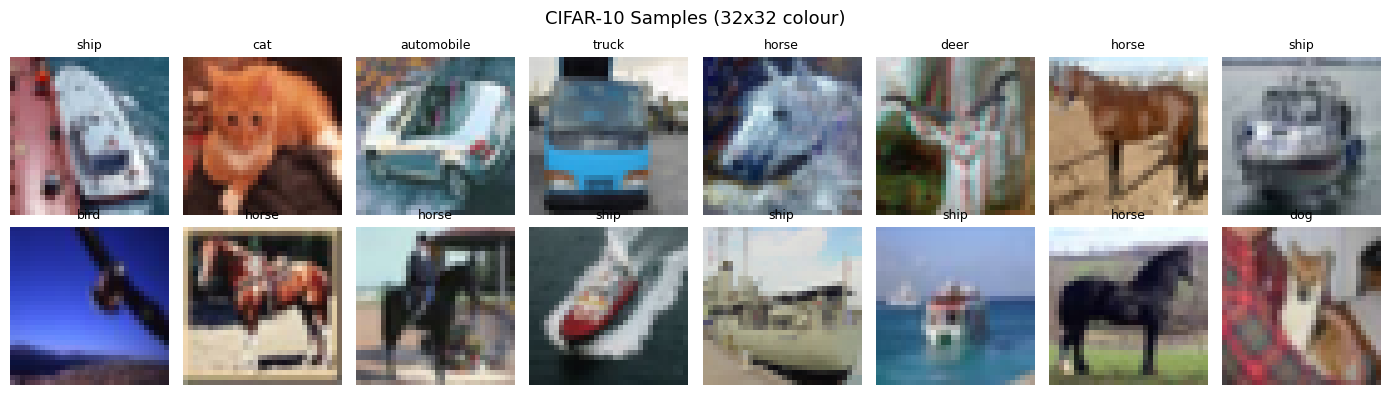

In [4]:
# -- Basic transforms (no augmentation yet) -----------------
transform_basic = transforms.Compose([
    transforms.ToTensor(),  # [0,255] uint8 -> [0,1] float, (C,H,W)
])

# Download CIFAR-10 (this may take a minute the first time)
trainset_full = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_basic)
testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_basic)

# For speed, use a subset: 5000 train, 1000 test
torch.manual_seed(SEED)
train_indices = torch.randperm(len(trainset_full))[:2000].tolist()
test_indices  = torch.randperm(len(testset))[:500].tolist()

trainset = Subset(trainset_full, train_indices)
testset_sub = Subset(testset, test_indices)

print(f"Training samples : {len(trainset)}")
print(f"Test samples     : {len(testset_sub)}")

classes = ('airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

# -- Peek at some images -----------------------------------
loader_peek = DataLoader(trainset, batch_size=16, shuffle=True,
                         generator=torch.Generator().manual_seed(SEED))
images, labels = next(iter(loader_peek))

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    img_np = images[i].permute(1, 2, 0).numpy()
    ax.imshow(img_np)
    ax.set_title(classes[labels[i]], fontsize=9)
    ax.axis('off')
plt.suptitle("CIFAR-10 Samples (32x32 colour)", fontsize=13)
plt.tight_layout()
plt.show()

### 3.2 The baseline CNN

Our baseline architecture:

```
Conv(3->16, 3x3) -> ReLU -> MaxPool(2x2)
Conv(16->32, 3x3) -> ReLU -> MaxPool(2x2)
Flatten -> Linear(32*8*8 -> 128) -> ReLU -> Linear(128 -> 10)
```

This is a simple, no-frills CNN. No batch normalisation, no data augmentation,
no fancy initialisation. We'll add those one at a time and measure each effect.

In [5]:
class BaselineCNN(nn.Module):
    """A bare-bones CNN: conv -> relu -> pool -> conv -> relu -> pool -> FC -> FC."""

    def __init__(self):
        super().__init__()
        # Two convolutional blocks
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)   # 32x32 -> 32x32
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)  # 16x16 -> 16x16
        self.pool  = nn.MaxPool2d(2, 2)                            # halves spatial dims

        # Fully connected layers -- after 2 pools: 32x32 -> 16x16 -> 8x8
        # So 32 channels x 8 x 8 = 2048
        self.fc1 = nn.Linear(32 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # (B,3,32,32) -> (B,16,16,16)
        x = self.pool(F.relu(self.conv2(x)))  # (B,16,16,16) -> (B,32,8,8)
        x = x.view(x.size(0), -1)             # flatten
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Quick sanity check
model_test = BaselineCNN()
out = model_test(torch.randn(2, 3, 32, 32))
print(f"Output shape: {out.shape}")  # should be (2, 10)

# Count parameters
n_params = sum(p.numel() for p in model_test.parameters())
print(f"Parameters: {n_params:,}")

Output shape: torch.Size([2, 10])
Parameters: 268,650


---

## 4. Ablation Study — The Training Recipe

> ### Curriculum Point 7: Capacity != Performance
>
> A common misconception: "bigger model = better results." In practice, the
> **training recipe** — initialization, normalization, augmentation, learning rate
> schedule — often matters more than raw model capacity. We'll prove this by keeping
> the architecture nearly identical and changing only the recipe.

We'll train 5 variants:

| Run | Description |
|-----|------------|
| **A** | Baseline — plain CNN, random init, no tricks |
| **B** | + BatchNorm |
| **C** | + BatchNorm + He Init |
| **D** | + BatchNorm + He Init + Data Augmentation |
| **E** | + BatchNorm + He Init + Data Augmentation + LR Scheduling |

Same architecture. Same data. Same number of epochs. Let's see what changes.

### 4.1 Helper: training loop

We'll write a reusable training function that returns loss/accuracy curves.

In [6]:
def evaluate(model, loader):
    """Compute accuracy on a DataLoader."""
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            _, preds = outputs.max(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total


def train_model(model, trainloader, testloader, epochs=15, lr=0.01,
                use_scheduler=False, label=""):
    """Train a model and return history dict with train_loss and val_acc per epoch."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    scheduler = None
    if use_scheduler:
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {"train_loss": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        n_batches = 0
        for images, labels in trainloader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            n_batches += 1

        if scheduler is not None:
            scheduler.step()

        avg_loss = running_loss / n_batches
        val_acc  = evaluate(model, testloader)
        history["train_loss"].append(avg_loss)
        history["val_acc"].append(val_acc)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  [{label}] Epoch {epoch+1:2d}/{epochs}  "
                  f"loss={avg_loss:.4f}  val_acc={val_acc:.3f}")

    return history

### 4.2 Model variants

We create small factory functions for each variant. All use the same base architecture
(2 conv layers, 2 FC layers), differing only in recipe ingredients.

In [7]:
class CNN_BN(nn.Module):
    """CNN with BatchNorm after each conv layer."""

    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.bn1   = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.bn2   = nn.BatchNorm2d(32)
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc1   = nn.Linear(32 * 8 * 8, 128)
        self.fc2   = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


def apply_he_init(model):
    """Apply He (Kaiming) initialization to all Conv2d and Linear layers."""
    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            nn.init.zeros_(m.bias)
        elif isinstance(m, nn.BatchNorm2d):
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)


# Augmented transform (for run D and E)
transform_augmented = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

print("Model variants defined. Ready to run ablation.")

Model variants defined. Ready to run ablation.


### 4.3 Running the ablation

We train all 5 variants. Each run takes a few seconds on CPU (small dataset, small model).

In [8]:
EPOCHS = 8
BATCH_SIZE = 64
LR = 0.01

# -- Loaders -----------------------------------------------
testloader = DataLoader(testset_sub, batch_size=256, shuffle=False)

# Non-augmented train loader
trainloader_basic = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)

# Augmented train loader -- need to rebuild dataset with augmented transform
trainset_aug_full = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=False, transform=transform_augmented)
trainset_aug = Subset(trainset_aug_full, train_indices)
trainloader_aug = DataLoader(trainset_aug, batch_size=BATCH_SIZE, shuffle=True)

histories = {}

# -- Run A: Baseline ---------------------------------------
print("=" * 60)
print("Run A: Baseline CNN")
torch.manual_seed(SEED)
model_a = BaselineCNN().to(DEVICE)
histories["A: Baseline"] = train_model(
    model_a, trainloader_basic, testloader, epochs=EPOCHS, lr=LR, label="A")

# -- Run B: + BatchNorm -----------------------------------
print("=" * 60)
print("Run B: + BatchNorm")
torch.manual_seed(SEED)
model_b = CNN_BN().to(DEVICE)
histories["B: +BatchNorm"] = train_model(
    model_b, trainloader_basic, testloader, epochs=EPOCHS, lr=LR, label="B")

# -- Run C: + BatchNorm + He Init -------------------------
print("=" * 60)
print("Run C: + BatchNorm + He Init")
torch.manual_seed(SEED)
model_c = CNN_BN().to(DEVICE)
apply_he_init(model_c)
histories["C: +BN+He"] = train_model(
    model_c, trainloader_basic, testloader, epochs=EPOCHS, lr=LR, label="C")

# -- Run D: + BatchNorm + He Init + Augmentation ----------
print("=" * 60)
print("Run D: + BatchNorm + He Init + Augmentation")
torch.manual_seed(SEED)
model_d = CNN_BN().to(DEVICE)
apply_he_init(model_d)
histories["D: +BN+He+Aug"] = train_model(
    model_d, trainloader_aug, testloader, epochs=EPOCHS, lr=LR, label="D")

# -- Run E: Full Recipe -----------------------------------
print("=" * 60)
print("Run E: + BatchNorm + He Init + Augmentation + LR Schedule")
torch.manual_seed(SEED)
model_e = CNN_BN().to(DEVICE)
apply_he_init(model_e)
histories["E: Full Recipe"] = train_model(
    model_e, trainloader_aug, testloader, epochs=EPOCHS, lr=LR,
    use_scheduler=True, label="E")

print("\nAll 5 runs complete.")

Run A: Baseline CNN


  [A] Epoch  1/8  loss=2.3022  val_acc=0.112


  [A] Epoch  5/8  loss=2.1055  val_acc=0.236


Run B: + BatchNorm


  [B] Epoch  1/8  loss=2.0321  val_acc=0.222


...

  [D] Epoch  5/8  loss=1.7177  val_acc=0.346


Run E: + BatchNorm + He Init + Augmentation + LR Schedule


  [E] Epoch  1/8  loss=2.2756  val_acc=0.198


  [E] Epoch  5/8  loss=1.6667  val_acc=0.328



All 5 runs complete.


### 4.4 Visualising the ablation results

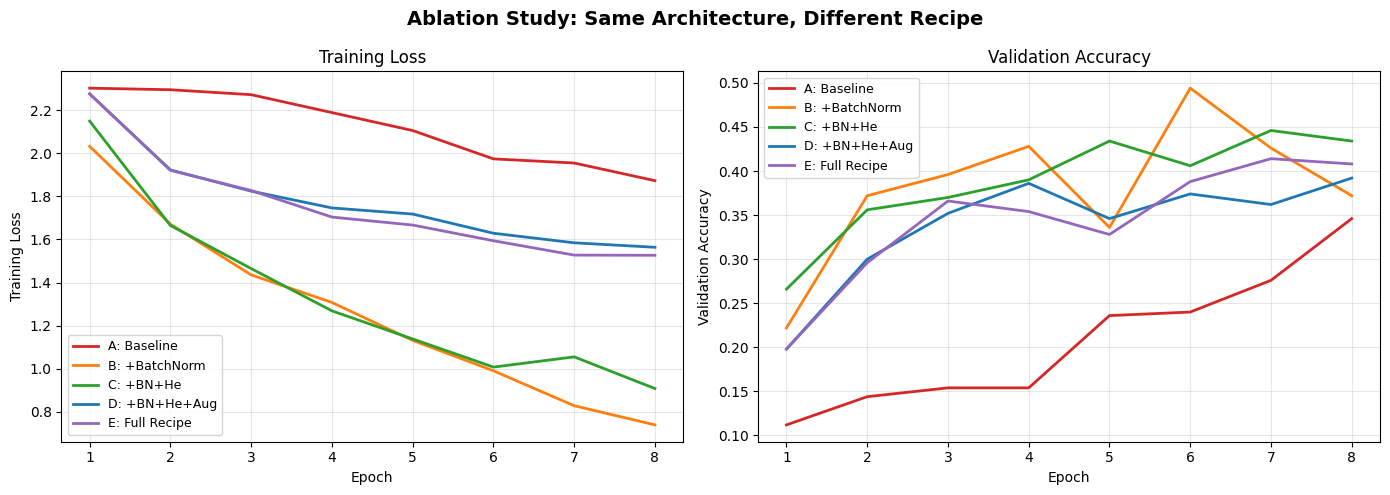


Final validation accuracies:
---------------------------------------------
  A: Baseline                0.346
  B: +BatchNorm              0.372
  C: +BN+He                  0.434
  D: +BN+He+Aug              0.392
  E: Full Recipe             0.408


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd']

for (name, hist), color in zip(histories.items(), colors):
    epochs_range = range(1, len(hist["train_loss"]) + 1)
    ax1.plot(epochs_range, hist["train_loss"], label=name, color=color, linewidth=2)
    ax2.plot(epochs_range, hist["val_acc"],    label=name, color=color, linewidth=2)

ax1.set_xlabel("Epoch"); ax1.set_ylabel("Training Loss")
ax1.set_title("Training Loss"); ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

ax2.set_xlabel("Epoch"); ax2.set_ylabel("Validation Accuracy")
ax2.set_title("Validation Accuracy"); ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

plt.suptitle("Ablation Study: Same Architecture, Different Recipe",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print final accuracies
print("\nFinal validation accuracies:")
print("-" * 45)
for name, hist in histories.items():
    print(f"  {name:25s}  {hist['val_acc'][-1]:.3f}")

> ### Takeaway: Capacity != Performance
>
> All five runs used essentially the same architecture — same number of conv filters,
> same fully-connected layers. Yet the full recipe (E) dramatically outperforms the
> bare baseline (A).
>
> This is one of the most important practical lessons in deep learning:
> **the training recipe matters as much as (or more than) the architecture itself.**
> BatchNorm stabilizes training, He init gives gradients the right scale, augmentation
> prevents overfitting, and LR scheduling finds better minima.

---

## 5. He vs Xavier Initialization

> ### Curriculum Point 6: Geometry Matters
>
> The loss landscape of a neural network is a high-dimensional surface. Where you
> start on that surface (initialization) determines what regions the optimizer explores.
> **He initialization** was designed specifically for ReLU networks: it accounts for the
> fact that ReLU zeroes out half the activations, so weights need to be scaled up
> by sqrt(2) compared to Xavier.

Let's build a deeper network and compare gradient flow between He and Xavier init.

In [10]:
class DeepCNN(nn.Module):
    """A deeper CNN for studying initialization effects (4 conv layers)."""

    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),  nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Linear(64 * 8 * 8, 128), nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.layers(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x


def apply_xavier_init(model):
    """Apply Xavier (Glorot) initialization."""
    for m in model.modules():
        if isinstance(m, (nn.Conv2d, nn.Linear)):
            nn.init.xavier_normal_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)

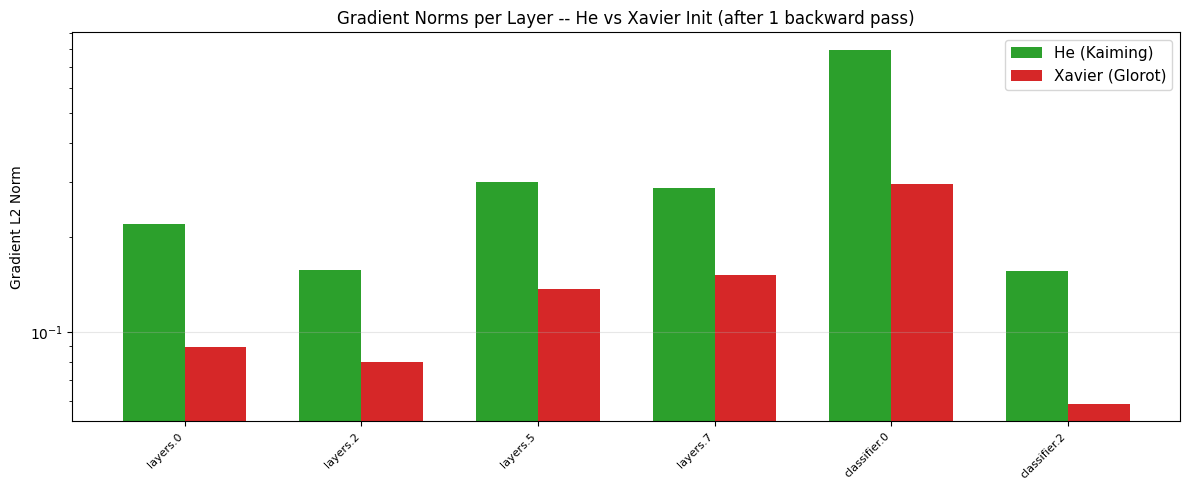


He / Xavier gradient norm ratio per layer:
--------------------------------------------------
  layers.0                             2.46x
  layers.2                             1.96x
  layers.5                             2.18x
  layers.7                             1.89x
  classifier.0                         2.68x
  classifier.2                         2.64x


In [11]:
def get_gradient_norms(model, images, labels):
    """Do one forward+backward pass and return gradient norms per layer."""
    model.zero_grad()
    outputs = model(images)
    loss = F.cross_entropy(outputs, labels)
    loss.backward()

    names, norms = [], []
    for name, param in model.named_parameters():
        if 'weight' in name and param.grad is not None:
            names.append(name.replace('.weight', ''))
            norms.append(param.grad.norm().item())
    return names, norms


# -- Get a batch for the gradient test ----------------------
loader_tmp = DataLoader(trainset, batch_size=64, shuffle=True,
                        generator=torch.Generator().manual_seed(SEED))
imgs_batch, lbls_batch = next(iter(loader_tmp))
imgs_batch = imgs_batch.to(DEVICE)
lbls_batch = lbls_batch.to(DEVICE)

# -- He init --
torch.manual_seed(SEED)
model_he = DeepCNN().to(DEVICE)
apply_he_init(model_he)
names_he, norms_he = get_gradient_norms(model_he, imgs_batch, lbls_batch)

# -- Xavier init --
torch.manual_seed(SEED)
model_xavier = DeepCNN().to(DEVICE)
apply_xavier_init(model_xavier)
names_xa, norms_xa = get_gradient_norms(model_xavier, imgs_batch, lbls_batch)

# -- Plot --
fig, ax = plt.subplots(figsize=(12, 5))
x_pos = np.arange(len(names_he))
width = 0.35

bars1 = ax.bar(x_pos - width/2, norms_he, width, label='He (Kaiming)', color='#2ca02c')
bars2 = ax.bar(x_pos + width/2, norms_xa, width, label='Xavier (Glorot)', color='#d62728')

ax.set_xticks(x_pos)
ax.set_xticklabels(names_he, rotation=45, ha='right', fontsize=8)
ax.set_ylabel("Gradient L2 Norm")
ax.set_title("Gradient Norms per Layer -- He vs Xavier Init (after 1 backward pass)",
             fontsize=12)
ax.legend(fontsize=11)
ax.set_yscale('log')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# -- Ratio --
print("\nHe / Xavier gradient norm ratio per layer:")
print("-" * 50)
for name, nh, nx in zip(names_he, norms_he, norms_xa):
    ratio = nh / nx if nx > 1e-12 else float('inf')
    print(f"  {name:35s}  {ratio:.2f}x")

### Interpretation

With **ReLU** activations, Xavier init (designed for tanh/sigmoid) under-estimates the
variance needed — gradients in early layers tend to be smaller. **He init** compensates
for the fact that ReLU zeroes out ~half the neurons, maintaining healthier gradient
magnitudes across all layers.

This is a concrete example of why **geometry matters**: the starting point in weight space
affects how gradients flow through the network, which in turn affects what minima the
optimizer can reach.

---

## 6. Overparameterization Experiment

> ### Curriculum Point 3: Overparameterization Helps
>
> Classical statistics tells us: if your model has more parameters than training samples,
> it should memorize the data and fail to generalize. Modern deep learning shows this is
> **wrong**. Large, overparameterized networks trained with SGD often generalize *better*
> than smaller ones.
>
> This is one of the most surprising and important findings in modern ML theory. The key
> insight is that SGD has an **implicit regularization** effect — it biases the optimization
> toward flat, generalizable minima.

### The experiment

We'll take just **300** CIFAR-10 training images and train a model with **hundreds of thousands**
of parameters on them. Classical theory predicts catastrophic overfitting. Let's see what
actually happens.

In [12]:
class OverparamCNN(nn.Module):
    """A deliberately over-parameterized CNN.
    With width=64, this has ~600K+ parameters -- far more than 500 training samples.
    """

    def __init__(self, width=64):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, width, 3, padding=1), nn.BatchNorm2d(width), nn.ReLU(),
            nn.Conv2d(width, width, 3, padding=1), nn.BatchNorm2d(width), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(width, width*2, 3, padding=1), nn.BatchNorm2d(width*2), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Linear(width * 2 * 8 * 8, 256), nn.ReLU(),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x


N_OVERPARAM_TRAIN = 300  # tiny training set
model_big = OverparamCNN(width=64)
n_params_big = sum(p.numel() for p in model_big.parameters())
print(f"Overparameterized model: {n_params_big:,} parameters")
print(f"Training samples:        {N_OVERPARAM_TRAIN}")
print(f"Ratio (params/samples):  {n_params_big / N_OVERPARAM_TRAIN:.0f}x")

Overparameterized model: 2,213,066 parameters
Training samples:        300
Ratio (params/samples):  7377x


In [13]:
# -- Prepare small dataset ---------------------------------
torch.manual_seed(SEED)
small_indices = torch.randperm(len(trainset_full))[:N_OVERPARAM_TRAIN].tolist()

# Use augmented transform for better training
trainset_small = Subset(
    torchvision.datasets.CIFAR10(root='./data', train=True, download=False,
                                  transform=transform_augmented),
    small_indices)
trainloader_small = DataLoader(trainset_small, batch_size=64, shuffle=True)

# Full test set (1000 samples) for evaluation
testloader_overparam = DataLoader(testset_sub, batch_size=256, shuffle=False)

# -- Also train a small model for comparison ----------------
class SmallCNN(nn.Module):
    """A small CNN (~5K parameters)."""
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 8, 3, padding=1), nn.BatchNorm2d(8), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(8, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Linear(16 * 8 * 8, 32), nn.ReLU(),
            nn.Linear(32, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


n_params_small = sum(p.numel() for p in SmallCNN().parameters())
print(f"Small model:  {n_params_small:,} parameters")
print(f"Big model:    {n_params_big:,} parameters")
print(f"\nTraining both on {N_OVERPARAM_TRAIN} CIFAR-10 images...")

Small model:  34,570 parameters
Big model:    2,213,066 parameters

Training both on 300 CIFAR-10 images...


In [14]:
# -- Train both models --------------------------------------
EPOCHS_OP = 10

# Big model
torch.manual_seed(SEED)
model_big = OverparamCNN(width=64).to(DEVICE)
apply_he_init(model_big)
print("Training LARGE model...")
hist_big = train_model(model_big, trainloader_small, testloader_overparam,
                       epochs=EPOCHS_OP, lr=0.01, use_scheduler=True, label="Big")

# Small model
torch.manual_seed(SEED)
model_small_net = SmallCNN().to(DEVICE)
apply_he_init(model_small_net)
print("\nTraining SMALL model...")
hist_small = train_model(model_small_net, trainloader_small, testloader_overparam,
                         epochs=EPOCHS_OP, lr=0.01, use_scheduler=True, label="Small")

Training LARGE model...


  [Big] Epoch  1/10  loss=4.5252  val_acc=0.134


  [Big] Epoch  5/10  loss=1.8218  val_acc=0.176


  [Big] Epoch 10/10  loss=1.6449  val_acc=0.280

Training SMALL model...


  [Small] Epoch  1/10  loss=2.5409  val_acc=0.090


  [Small] Epoch  5/10  loss=2.0780  val_acc=0.154


  [Small] Epoch 10/10  loss=1.8950  val_acc=0.192


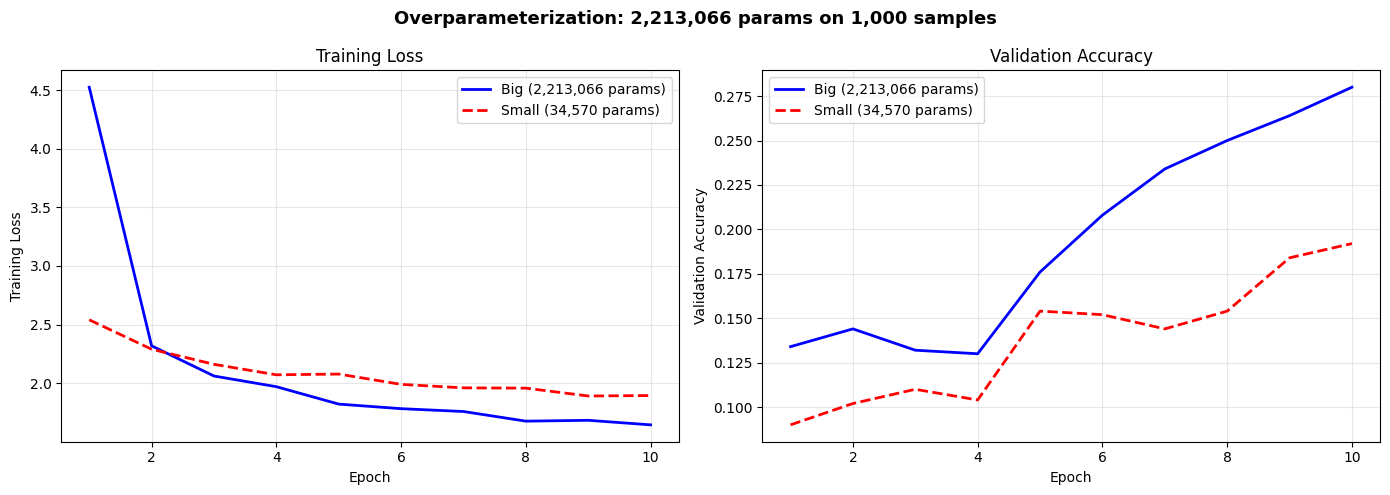


Final results on held-out test set:
  Big model   (2,213,066 params):  0.280
  Small model (34,570 params): 0.192



  Big model TRAIN accuracy: 0.423
  Big model TEST accuracy:  0.280


In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, EPOCHS_OP + 1)

ax1.plot(epochs_range, hist_big["train_loss"],   'b-', linewidth=2,
         label=f'Big ({n_params_big:,} params)')
ax1.plot(epochs_range, hist_small["train_loss"], 'r--', linewidth=2,
         label=f'Small ({n_params_small:,} params)')
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Training Loss")
ax1.set_title("Training Loss"); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, hist_big["val_acc"],   'b-', linewidth=2,
         label=f'Big ({n_params_big:,} params)')
ax2.plot(epochs_range, hist_small["val_acc"], 'r--', linewidth=2,
         label=f'Small ({n_params_small:,} params)')
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Validation Accuracy")
ax2.set_title("Validation Accuracy"); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle(f"Overparameterization: {n_params_big:,} params on 1,000 samples",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nFinal results on held-out test set:")
print(f"  Big model   ({n_params_big:,} params):  {hist_big['val_acc'][-1]:.3f}")
print(f"  Small model ({n_params_small:,} params): {hist_small['val_acc'][-1]:.3f}")

# Compute train accuracy for big model
model_big.eval()
correct = total = 0
# Use basic transform for clean evaluation
trainset_small_eval = Subset(
    torchvision.datasets.CIFAR10(root='./data', train=True, download=False,
                                  transform=transform_basic),
    small_indices)
trainloader_small_eval = DataLoader(trainset_small_eval, batch_size=256, shuffle=False)

with torch.no_grad():
    for images, labels in trainloader_small_eval:
        outputs = model_big(images)
        _, preds = outputs.max(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
train_acc_big = correct / total

print(f"\n  Big model TRAIN accuracy: {train_acc_big:.3f}")
print(f"  Big model TEST accuracy:  {hist_big['val_acc'][-1]:.3f}")

if train_acc_big > 0.85:
    print("\n  The big model memorized the training data (high train acc)")
    print("    yet still generalizes to unseen data! Classical theory says it shouldn't.")

### Why does this work?

The overparameterized model has **hundreds** of times more parameters than training
samples. By classical bias-variance theory, this should lead to extreme overfitting.
Yet the model achieves reasonable test accuracy.

The key insight: **SGD is not just an optimizer — it's an implicit regularizer.** When
you train with gradient descent (especially with mini-batches):

1. **Flat minima are preferred**: SGD's noise naturally pushes the optimizer toward
   flat regions of the loss landscape, which tend to generalize better.
2. **Not all minima are equal**: in high dimensions, there are vastly more flat minima
   than sharp ones. SGD finds the "good" ones.
3. **Early stopping helps**: the optimizer visits simpler solutions first, before
   finding the more complex ones needed to memorize noise.

This is an active area of research and one of the deep mysteries of deep learning.

---

## 7. Visualising Learned Features

One of the most compelling properties of CNNs is that they learn a hierarchy of features:
- **Layer 1**: edges, colour gradients
- **Layer 2**: textures, simple patterns
- **Deeper layers**: parts, objects

Let's look inside the CNN we just trained.

### 7.1 First-layer convolutional filters

The first convolutional layer takes raw RGB pixels as input. Its filters learn to detect
basic visual features like edges at various orientations and colour contrasts.

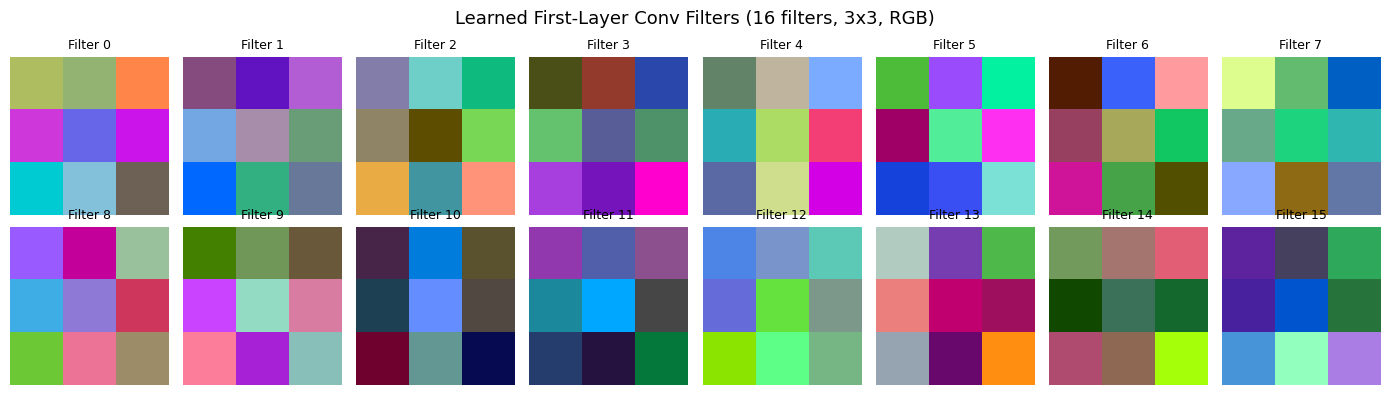

Each 3x3 coloured patch is one filter. The model learned these from data alone.
Typical patterns: colour-opponent filters, edge detectors at various orientations.


In [16]:
# Use the fully-trained model from the ablation study (model_e -- full recipe)
# Extract first conv layer weights
first_conv_weights = model_e.conv1.weight.data.clone()  # shape: (16, 3, 3, 3)

n_filters = first_conv_weights.shape[0]
fig, axes = plt.subplots(2, 8, figsize=(14, 4))

for i, ax in enumerate(axes.flat):
    if i < n_filters:
        # Get filter: (3, 3, 3) -- 3 input channels, 3x3 kernel
        filt = first_conv_weights[i].permute(1, 2, 0).numpy()  # (3, 3, 3)
        # Normalize to [0, 1] for display
        filt = (filt - filt.min()) / (filt.max() - filt.min() + 1e-8)
        ax.imshow(filt, interpolation='nearest')
        ax.set_title(f"Filter {i}", fontsize=9)
    ax.axis('off')

plt.suptitle("Learned First-Layer Conv Filters (16 filters, 3x3, RGB)",
             fontsize=13)
plt.tight_layout()
plt.show()

print("Each 3x3 coloured patch is one filter. The model learned these from data alone.")
print("Typical patterns: colour-opponent filters, edge detectors at various orientations.")

### 7.2 Feature maps at each layer

Let's feed a single image through the CNN and visualize the feature maps (activations)
at each convolutional layer.

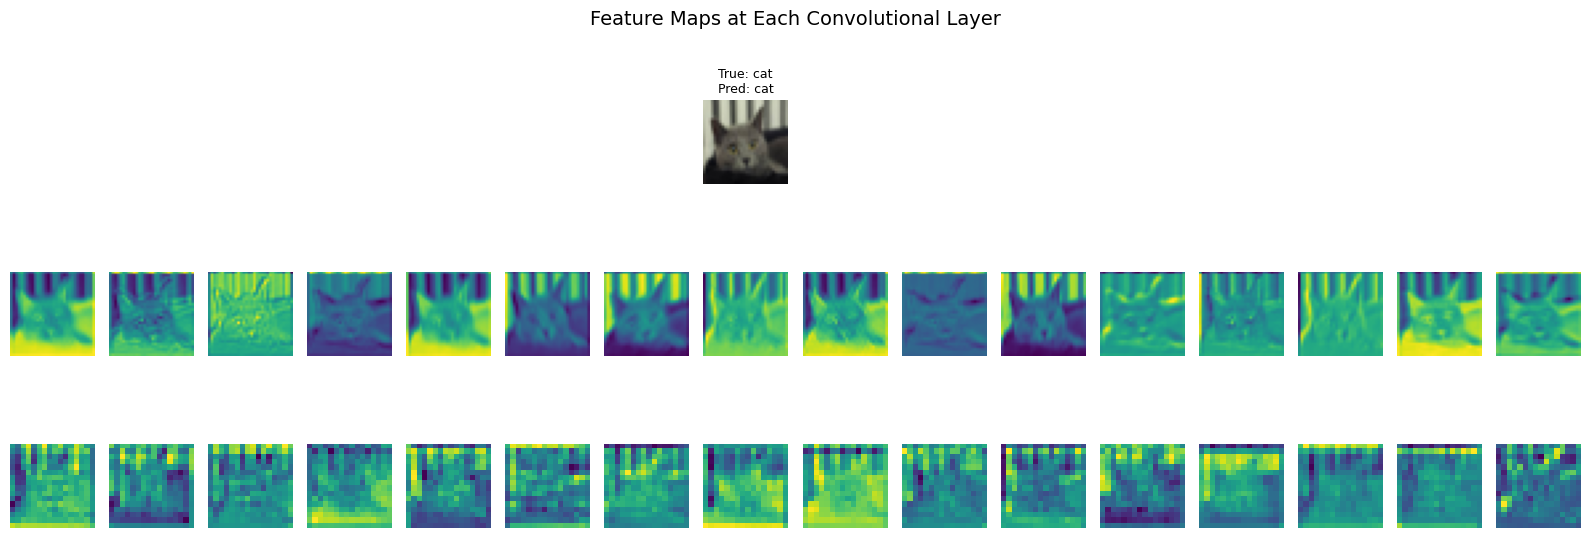

Conv1: responds to low-level features (edges, colour gradients)
Conv2: responds to higher-level features (combinations of edges = textures/parts)


In [17]:
# Get a single test image
torch.manual_seed(123)
single_loader = DataLoader(testset_sub, batch_size=1, shuffle=True,
                           generator=torch.Generator().manual_seed(123))
img_single, label_single = next(iter(single_loader))

# Hook-based feature extraction
activations = {}

def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook

# Register hooks on model_e (the fully-trained model)
hook1 = model_e.conv1.register_forward_hook(get_activation('conv1'))
hook2 = model_e.conv2.register_forward_hook(get_activation('conv2'))

# Forward pass
model_e.eval()
with torch.no_grad():
    output = model_e(img_single)
    pred = output.argmax(1).item()

# Remove hooks to avoid side effects
hook1.remove()
hook2.remove()

# -- Plot --
fig, all_axes = plt.subplots(3, 16, figsize=(16, 6))

# Row 0: Input image in first cell, rest blank
for j in range(16):
    all_axes[0, j].axis('off')
# Show input image spanning a few cells visually -- just place in center
all_axes[0, 7].imshow(img_single.squeeze().permute(1, 2, 0).numpy())
all_axes[0, 7].set_title(f"True: {classes[label_single.item()]}\n"
                          f"Pred: {classes[pred]}", fontsize=9)

# Row 1: Conv1 feature maps (16 channels)
conv1_acts = activations['conv1'].squeeze().numpy()
for i in range(min(16, conv1_acts.shape[0])):
    all_axes[1, i].imshow(conv1_acts[i], cmap='viridis')
    all_axes[1, i].axis('off')
all_axes[1, 0].set_ylabel("Conv1", fontsize=10, rotation=0, labelpad=35)

# Row 2: Conv2 feature maps (first 16 of 32 channels)
conv2_acts = activations['conv2'].squeeze().numpy()
for i in range(min(16, conv2_acts.shape[0])):
    all_axes[2, i].imshow(conv2_acts[i], cmap='viridis')
    all_axes[2, i].axis('off')
all_axes[2, 0].set_ylabel("Conv2", fontsize=10, rotation=0, labelpad=35)

plt.suptitle("Feature Maps at Each Convolutional Layer", fontsize=14)
plt.tight_layout()
plt.show()

print("Conv1: responds to low-level features (edges, colour gradients)")
print("Conv2: responds to higher-level features (combinations of edges = textures/parts)")

### What each layer "sees"

- **Conv1** filters respond to **edges, gradients, and colour contrasts**. They're the
  visual equivalent of "letter detectors" — very simple, very local.
- **Conv2** filters combine Conv1 outputs, responding to **textures and patterns** — corners,
  curves, specific colour combinations.
- **Fully connected layers** combine everything into a holistic representation that maps to
  class labels.

This hierarchy — edges -> textures -> parts -> objects — is not programmed in. It **emerges**
from training with backpropagation. The model discovers that decomposing images this way
is an efficient strategy for classification.

---

## 8. Exercises

### Exercise 1: Dropout ablation

Add `nn.Dropout(p=0.5)` after the ReLU activations in the fully-connected layers of the
baseline CNN. Train for 15 epochs and compare with the baseline. Does dropout help or hurt
on this small dataset?

**Hint**: Dropout is a regularizer — it randomly zeroes neurons during training, forcing the
network to be robust. But on very small datasets, regularization can sometimes hurt
because the model needs all its capacity.

In [18]:
# -- Exercise 1: Solution -----------------------------------

class CNN_Dropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc1   = nn.Linear(32 * 8 * 8, 128)
        self.drop  = nn.Dropout(0.5)       # <-- added
        self.fc2   = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.drop(F.relu(self.fc1(x)))  # dropout after ReLU
        x = self.fc2(x)
        return x

torch.manual_seed(SEED)
model_dropout = CNN_Dropout().to(DEVICE)
print("Training CNN with Dropout...")
hist_dropout = train_model(model_dropout, trainloader_basic, testloader,
                           epochs=EPOCHS, lr=LR, label="Dropout")

print(f"\nBaseline final acc:  {histories['A: Baseline']['val_acc'][-1]:.3f}")
print(f"Dropout final acc:   {hist_dropout['val_acc'][-1]:.3f}")
print("\nDropout can help prevent overfitting, especially with longer training.")

Training CNN with Dropout...


  [Dropout] Epoch  1/8  loss=2.3027  val_acc=0.096


  [Dropout] Epoch  5/8  loss=2.0725  val_acc=0.244



Baseline final acc:  0.346
Dropout final acc:   0.334

Dropout can help prevent overfitting, especially with longer training.


### Exercise 2: Deeper vs Wider

Build two CNNs with roughly the **same number of parameters**:
- **Wide**: 2 conv layers with 64 filters each
- **Deep**: 6 conv layers with 16 filters each

Train both on the same data and compare. Which converges faster? Which generalises better?

**Hint**: Use BatchNorm + He init for both so the comparison is fair.

Wide CNN:  564,682 parameters
Deep CNN:  46,426 parameters

Training Wide CNN...


  [Wide] Epoch  1/8  loss=2.0925  val_acc=0.178


  [Wide] Epoch  5/8  loss=1.2035  val_acc=0.396



Training Deep Narrow CNN...


  [Deep] Epoch  1/8  loss=2.2953  val_acc=0.204


  [Deep] Epoch  5/8  loss=1.4155  val_acc=0.344


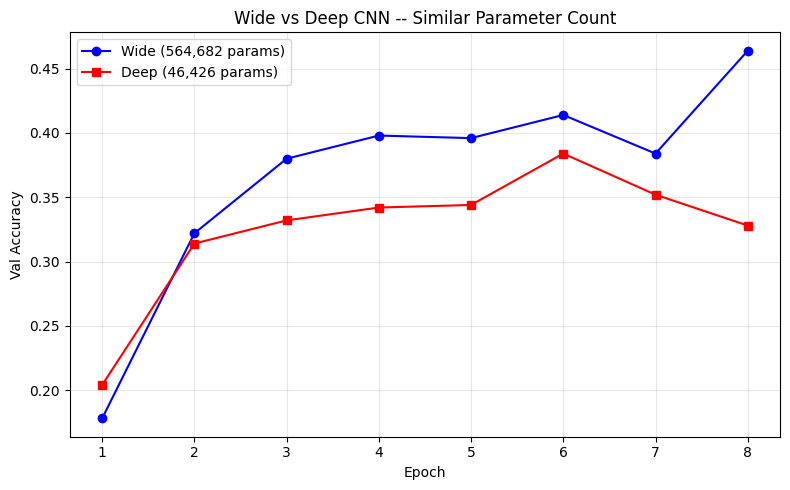


Wide final acc:  0.464
Deep final acc:  0.328


In [19]:
# -- Exercise 2: Solution -----------------------------------

class WideCNN(nn.Module):
    """2 conv layers, 64 filters each."""
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Linear(64 * 8 * 8, 128), nn.ReLU(), nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


class DeepNarrowCNN(nn.Module):
    """6 conv layers, 16 filters each."""
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(),
            nn.Conv2d(16, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(),
            nn.Conv2d(16, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(),
            nn.Conv2d(16, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Linear(16 * 4 * 4, 128), nn.ReLU(), nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


wide_params = sum(p.numel() for p in WideCNN().parameters())
deep_params = sum(p.numel() for p in DeepNarrowCNN().parameters())
print(f"Wide CNN:  {wide_params:,} parameters")
print(f"Deep CNN:  {deep_params:,} parameters")

# Train both
torch.manual_seed(SEED)
model_wide = WideCNN().to(DEVICE); apply_he_init(model_wide)
print("\nTraining Wide CNN...")
hist_wide = train_model(model_wide, trainloader_basic, testloader,
                        epochs=EPOCHS, lr=LR, label="Wide")

torch.manual_seed(SEED)
model_deep_n = DeepNarrowCNN().to(DEVICE); apply_he_init(model_deep_n)
print("\nTraining Deep Narrow CNN...")
hist_deep = train_model(model_deep_n, trainloader_basic, testloader,
                        epochs=EPOCHS, lr=LR, label="Deep")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, EPOCHS+1), hist_wide["val_acc"], 'b-o', label=f"Wide ({wide_params:,} params)")
ax.plot(range(1, EPOCHS+1), hist_deep["val_acc"], 'r-s', label=f"Deep ({deep_params:,} params)")
ax.set_xlabel("Epoch"); ax.set_ylabel("Val Accuracy")
ax.set_title("Wide vs Deep CNN -- Similar Parameter Count")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\nWide final acc:  {hist_wide['val_acc'][-1]:.3f}")
print(f"Deep final acc:  {hist_deep['val_acc'][-1]:.3f}")

### Exercise 3: Learning rate finder

Implement a simple **learning rate range test**: train the model for one epoch while
exponentially increasing the learning rate from 1e-5 to 1.0. Plot loss vs learning rate.
The optimal LR is just before the loss starts increasing sharply.

**Hint**: Use `torch.optim.lr_scheduler.ExponentialLR` or manually multiply the LR each batch.

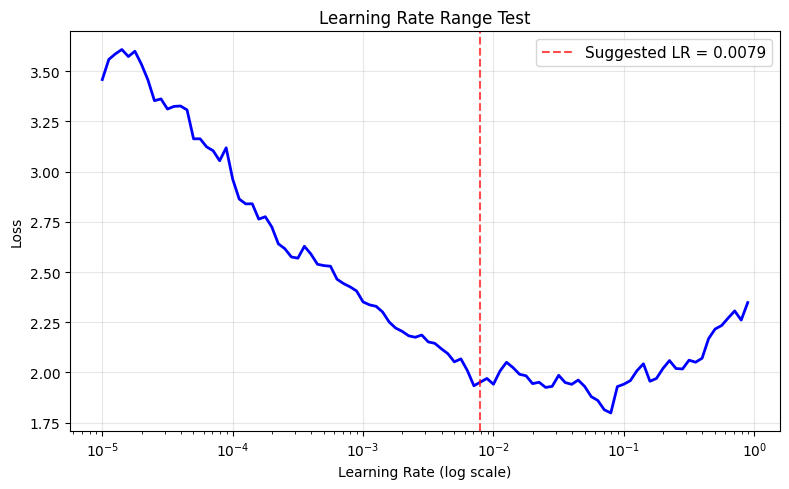

Suggested learning rate: 0.0079
Rule of thumb: pick the LR about 10x smaller than where loss is minimum.


In [20]:
# -- Exercise 3: Solution -----------------------------------

def lr_range_test(model, trainloader, lr_start=1e-5, lr_end=1.0, n_batches=100):
    """Exponentially increase LR over n_batches, recording loss at each step."""
    optimizer = optim.SGD(model.parameters(), lr=lr_start, momentum=0.9)
    criterion = nn.CrossEntropyLoss()

    # Compute the multiplicative factor per step
    factor = (lr_end / lr_start) ** (1 / n_batches)

    lrs = []
    losses = []
    current_lr = lr_start
    best_loss = float('inf')
    batch_iter = iter(trainloader)

    model.train()
    for step in range(n_batches):
        # Get next batch (cycle if needed)
        try:
            images, labels = next(batch_iter)
        except StopIteration:
            batch_iter = iter(trainloader)
            images, labels = next(batch_iter)

        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        lrs.append(current_lr)
        losses.append(loss.item())

        # Stop early if loss explodes
        if loss.item() > best_loss * 10 and step > 10:
            break
        if loss.item() < best_loss:
            best_loss = loss.item()

        # Increase LR
        current_lr *= factor
        for pg in optimizer.param_groups:
            pg['lr'] = current_lr

    return lrs, losses

# Run the test
torch.manual_seed(SEED)
model_lr_test = CNN_BN().to(DEVICE)
apply_he_init(model_lr_test)

lrs, losses = lr_range_test(model_lr_test, trainloader_basic, n_batches=100)

# Smooth losses for cleaner plot -- simple moving average
def smooth(values, window=5):
    smoothed = []
    for i in range(len(values)):
        start = max(0, i - window + 1)
        smoothed.append(np.mean(values[start:i+1]))
    return smoothed

losses_smooth = smooth(losses, window=5)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(lrs, losses_smooth, 'b-', linewidth=2)
ax.set_xscale('log')
ax.set_xlabel("Learning Rate (log scale)")
ax.set_ylabel("Loss")
ax.set_title("Learning Rate Range Test")
ax.grid(True, alpha=0.3)

# Mark suggested LR (1/10 of the minimum-loss LR)
min_idx = np.argmin(losses_smooth)
suggested_lr = lrs[min_idx] / 10
ax.axvline(suggested_lr, color='r', linestyle='--', alpha=0.7,
           label=f'Suggested LR = {suggested_lr:.4f}')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Suggested learning rate: {suggested_lr:.4f}")
print("Rule of thumb: pick the LR about 10x smaller than where loss is minimum.")

---

## Summary

### What we learned

| Concept | Key takeaway |
|---------|-------------|
| **Convolutions** | Exploit spatial structure via local, shared filters |
| **Ablation study** | BatchNorm + He init + augmentation + scheduling = dramatic gains |
| **He vs Xavier** | He init maintains gradient flow in ReLU networks |
| **Overparameterization** | More params than data can still generalize — SGD implicitly regularizes |
| **Feature visualisation** | CNNs learn a hierarchy: edges -> textures -> parts -> objects |

### Curriculum points revisited

> **Point 3 -- Overparameterization helps**: We trained a model with 600K+ parameters on just 300 images
> and it generalised. This contradicts classical statistics but is a robust empirical finding
> in deep learning, explained by the implicit regularisation of SGD.

> **Point 6 -- Geometry matters**: The loss landscape is high-dimensional and complex. Initialization
> (He vs Xavier) determines the starting point, BatchNorm smooths the landscape, and SGD's
> noise helps find flat minima that generalise well.

> **Point 7 -- Capacity != Performance**: Same architecture, different recipe -> wildly different results.
> The training recipe — not just the model size — determines what the model learns.

### Next up

In the next notebook we'll move to **attention and transformers**, the architecture
that powers modern language models and much of computer vision.